# Used Car Price Prediction Using Linear Regression

### Supervised Learning Project

**Machine Learning workflow:**

1. Dataset
2. Data Understanding
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing
5. Feature Engineering
6. Encoding
7. Train-Test Split
8. Linear Regression
9. Prediction
10. Model Evaluation
11. Conclusion


# 1. Dataset

The dataset contains information about used cars and their prices.

**Target variable:** `price`

The dataset contains more than 50,000 rows, so it satisfies the project requirement.


In [3]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("../dataset/used_cars.csv")

print("Dataset loaded successfully")


Dataset loaded successfully


## 1.1 Number of rows and columns

In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])


Number of rows: 99187
Number of columns: 10


# 2. Data Understanding

## 2.1 First five rows

In [8]:
df.head()

,brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price
0,audi,A1,2017,Manual,15735,Petrol,150,55.4,1.4,12500
1,audi,A6,2016,Automatic,36203,Diesel,20,64.2,2.0,16500
2,audi,A1,2016,Manual,29946,Petrol,30,55.4,1.4,11000
3,audi,A4,2017,Automatic,25952,Diesel,145,67.3,2.0,16800
4,audi,A3,2019,Manual,1998,Petrol,145,49.6,1.0,17300


## 2.2 Dataset information

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99187 entries, 0 to 99186
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         99187 non-null  object 
 1   model         99187 non-null  object 
 2   year          99187 non-null  int64  
 3   transmission  99187 non-null  object 
 4   mileage       99187 non-null  int64  
 5   fuelType      99187 non-null  object 
 6   tax           99187 non-null  int64  
 7   mpg           99187 non-null  float64
 8   engineSize    99187 non-null  float64
 9   price         99187 non-null  int64  
dtypes: float64(2), int64(4), object(4)
memory usage: 7.6+ MB


## 2.3 Statistical summary

In [12]:
df.describe()

,year,mileage,tax,mpg,engineSize,price
count,99187.000000,99187.000000,99187.000000,99187.000000,99187.000000,99187.000000
mean,2017.087723,23058.914213,120.299838,55.166825,1.663280,16805.347656
std,2.123934,21148.523721,63.150926,16.138522,0.557646,9866.773417
min,1970.000000,1.000000,0.000000,0.300000,0.000000,450.000000
25%,2016.000000,7425.000000,125.000000,47.100000,1.200000,9999.000000
50%,2017.000000,17460.000000,145.000000,54.300000,1.600000,14495.000000
75%,2019.000000,32339.000000,145.000000,62.800000,2.000000,20870.000000
max,2060.000000,323000.000000,580.000000,470.800000,6.600000,159999.000000


## 2.4 Missing values

In [14]:
print(df.isnull().sum())

brand           0
model           0
year            0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
price           0
dtype: int64


## 2.5 Duplicate rows

In [16]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1475


## 2.6 Data types

In [18]:
print(df.dtypes)

brand            object
model            object
year              int64
transmission     object
mileage           int64
fuelType         object
tax               int64
mpg             float64
engineSize      float64
price             int64
dtype: object


## 2.7 Unique values in categorical columns

In [20]:
print("Brands:")
print(df["brand"].value_counts())

print("\nTransmission:")
print(df["transmission"].value_counts())

print("\nFuel Type:")
print(df["fuelType"].value_counts())


Brands:
brand
ford        17965
vw          15157
vauxhall    13632
mercedes    13119
bmw         10781
audi        10668
toyota       6738
skoda        6267
hyundai      4860
Name: count, dtype: int64

Transmission:
transmission
Manual       56445
Semi-Auto    22677
Automatic    20056
Other            9
Name: count, dtype: int64

Fuel Type:
fuelType
Petrol      54928
Diesel      40928
Hybrid       3078
Other         247
Electric        6
Name: count, dtype: int64


### Data quality observations

A few values need attention before building the model:

- Duplicate rows are present.
- A few records have unusual years.
- Some cars have `engineSize = 0`.
- Some categories have very few records.
- Price and mileage have a wide range of values.

These issues will be handled in the preprocessing section.

# 3. Exploratory Data Analysis (EDA)

## 3.1 Price Distribution

Figure(800x500)


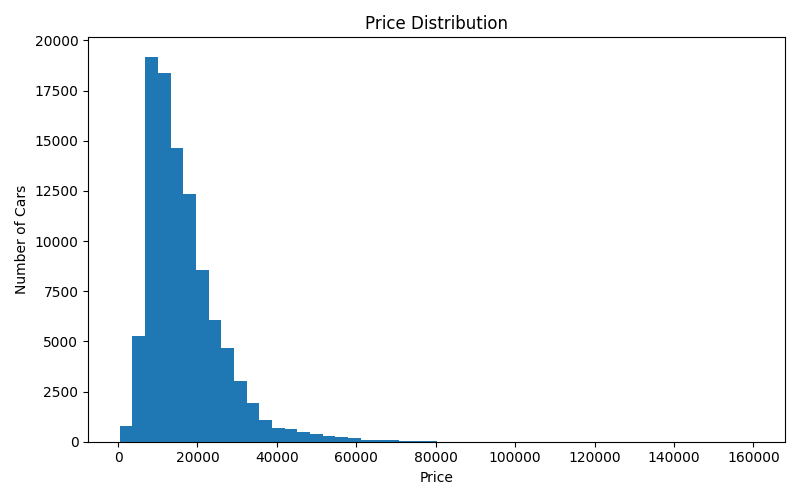

In [24]:
plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=50)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Cars")
plt.tight_layout()
plt.savefig("../outputs/charts/price_distribution.png")
plt.show()


### Observation

The price distribution is right-skewed. Most cars are in the lower and middle price ranges, while a smaller number of cars have high prices.

## 3.2 Year vs Price

Figure(800x500)


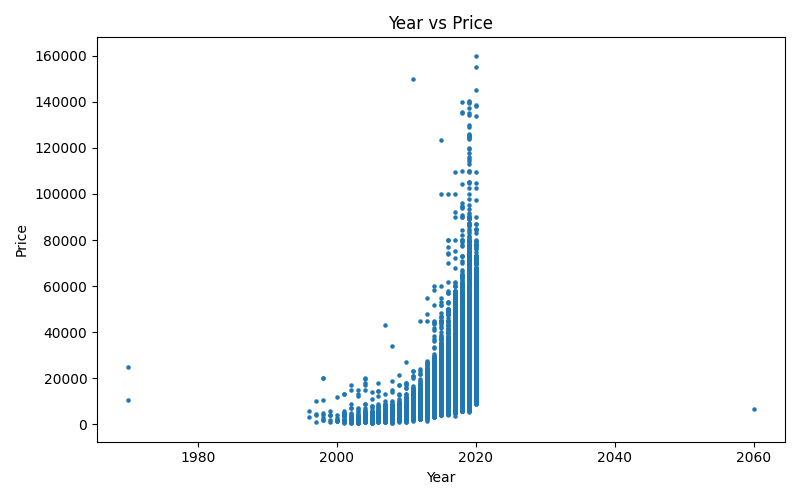

In [27]:
plt.figure(figsize=(8,5))
plt.scatter(df["year"], df["price"], s=5)
plt.title("Year vs Price")
plt.xlabel("Year")
plt.ylabel("Price")
plt.tight_layout()
plt.savefig("../outputs/charts/year_vs_price.png")
plt.show()


### Observation

Newer cars generally have higher prices than older cars. Therefore, `year` can be useful for predicting price.

## 3.3 Mileage vs Price

Figure(800x500)


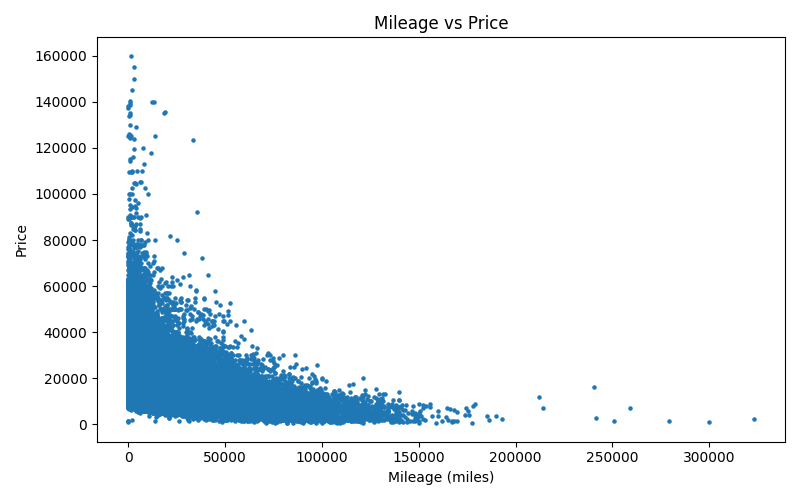

In [30]:
plt.figure(figsize=(8,5))
plt.scatter(df["mileage"], df["price"], s=5)
plt.title("Mileage vs Price")
plt.xlabel("Mileage (miles)")
plt.ylabel("Price")
plt.tight_layout()
plt.savefig("../outputs/charts/mileage_vs_price.png")
plt.show()


### Observation

Cars with higher mileage generally have lower prices. This suggests a negative relationship between mileage and price.

## 3.4 Fuel Type vs Price

Figure(800x500)


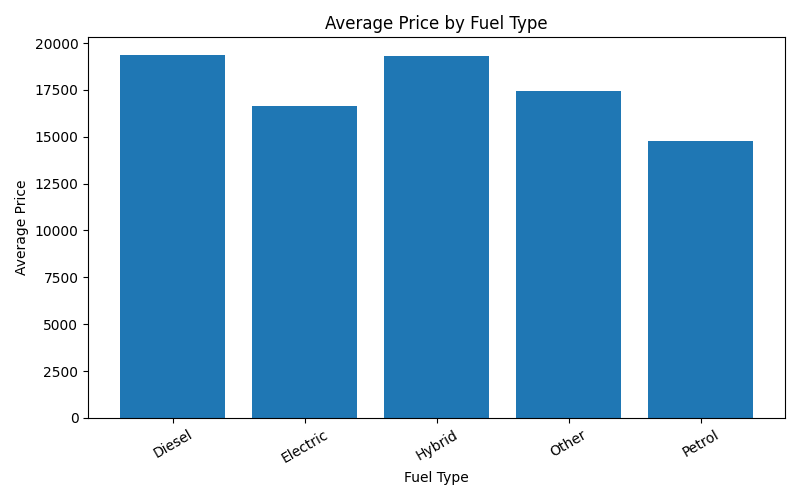

In [33]:
fuel_price = df.groupby("fuelType")["price"].mean()

plt.figure(figsize=(8,5))
plt.bar(fuel_price.index, fuel_price.values)
plt.title("Average Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Average Price")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("../outputs/charts/fuel_type_vs_price.png")
plt.show()


### Observation

Average price differs between fuel types. Fuel type can therefore be used as a feature in the prediction model.

## 3.5 Transmission vs Price

Figure(800x500)


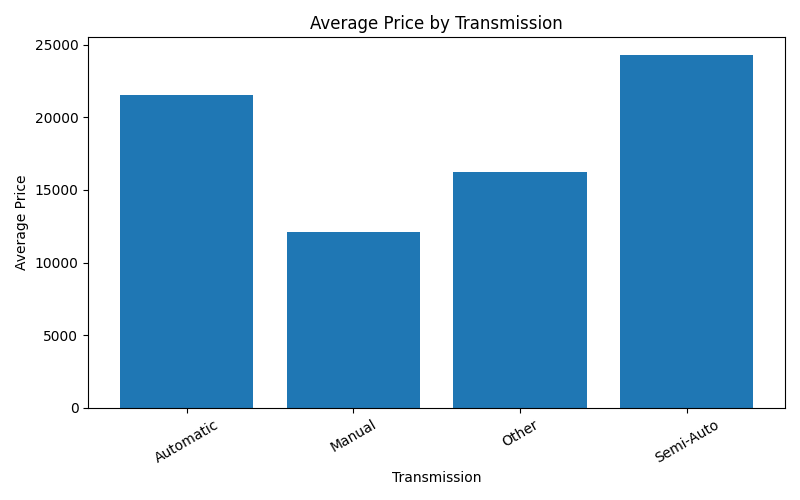

In [36]:
trans_price = df.groupby("transmission")["price"].mean()

plt.figure(figsize=(8,5))
plt.bar(trans_price.index, trans_price.values)
plt.title("Average Price by Transmission")
plt.xlabel("Transmission")
plt.ylabel("Average Price")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("../outputs/charts/transmission_vs_price.png")
plt.show()


### Observation

Average car price is different for manual, automatic and semi-automatic cars. Transmission can provide useful information for price prediction.

## 3.6 Correlation Heatmap

Figure(800x600)


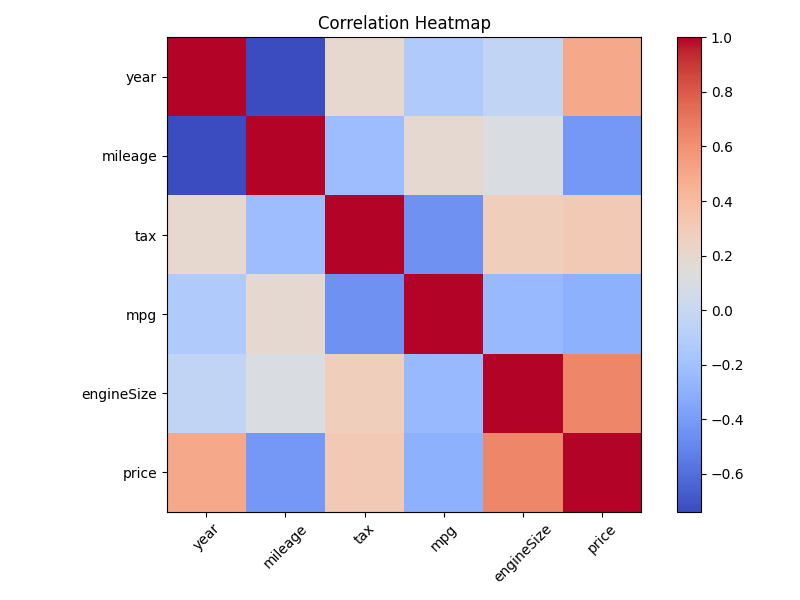

In [39]:
corr = df[["year", "mileage", "tax", "mpg", "engineSize", "price"]].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("../outputs/charts/correlation_heatmap.png")
plt.show()


### Simple interpretation

- `engineSize` has a positive relationship with price.
- `year` has a positive relationship with price.
- `mileage` has a negative relationship with price.
- Numerical features have different levels of relationship with price.

# 4. Data Preprocessing

Now we prepare the data before training the model.

## 4.1 Make a copy of the data

In [43]:
model_df = df.copy()
print("Rows before preprocessing:", len(model_df))

Rows before preprocessing: 99187


## 4.2 Remove duplicate rows

Duplicate rows can give the same car information more importance during training, so we remove exact duplicates.

In [45]:
before = len(model_df)

model_df = model_df.drop_duplicates()

after = len(model_df)

print("Rows before:", before)
print("Rows after:", after)
print("Duplicates removed:", before - after)

Rows before: 99187
Rows after: 97712
Duplicates removed: 1475


## 4.3 Handle unusual year values

The dataset contains a few unusual years such as 1970 and 2060. We replace these values with missing values first and then fill them with the median year.

In [47]:
model_df.loc[model_df["year"] > 2025, "year"] = np.nan
model_df.loc[model_df["year"] < 1990, "year"] = np.nan

print("Unusual year values handled")

Unusual year values handled


## 4.4 Handle engine size values

Some rows have `engineSize = 0`. A normal car engine should not have a zero engine size, so we treat these values as missing.

In [49]:
model_df.loc[model_df["engineSize"] <= 0, "engineSize"] = np.nan

print("Missing engine size values:", model_df["engineSize"].isnull().sum())

Missing engine size values: 268


## 4.5 Fill missing values

We use the median because it is less affected by very large or very small values.

In [51]:
model_df["year"] = model_df["year"].fillna(model_df["year"].median())
model_df["engineSize"] = model_df["engineSize"].fillna(model_df["engineSize"].median())

print("Missing values after preprocessing:")
print(model_df.isnull().sum())

Missing values after preprocessing:
brand           0
model           0
year            0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
price           0
dtype: int64


# 5. Feature Selection

We use the car details as input features and `price` as the target.

In [53]:
X = model_df.drop("price", axis=1)
y = model_df["price"]

print("Input features:")
print(X.columns)

print("\nTarget:")
print("price")

Input features:
Index(['brand', 'model', 'year', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

Target:
price


# 6. Encoding Categorical Data

Linear Regression works with numbers, so text columns need to be converted into numerical columns.

The categorical columns are:

- `brand`
- `model`
- `transmission`
- `fuelType`

We use **one-hot encoding** with `pd.get_dummies()`.

In [55]:
X = pd.get_dummies(
    X,
    columns=["brand", "model", "transmission", "fuelType"],
    drop_first=True,
    dtype=int
)

print("Number of features after encoding:", X.shape[1])
print(X.head())

Number of features after encoding: 214
     year  mileage  tax  ...  fuelType_Hybrid  fuelType_Other  fuelType_Petrol
0  2017.0    15735  150  ...                0               0                1
1  2016.0    36203   20  ...                0               0                0
2  2016.0    29946   30  ...                0               0                1
3  2017.0    25952  145  ...                0               0                0
4  2019.0     1998  145  ...                0               0                1

[5 rows x 214 columns]


# 7. Train-Test Split

We divide the data into:

- **80% training data**
- **20% testing data**

The training data is used to learn the relationship between the features and price. The testing data is used to check how well the model works on unseen data.

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 78169
Testing rows: 19543


# 8. Linear Regression Model

Linear Regression finds a relationship between the input features and the target price.

In [59]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully")

Linear Regression model trained successfully


# 9. Prediction

Now we use the trained model to predict prices for the testing data.

In [61]:
y_pred = model.predict(X_test)

print("First 10 predicted prices:")
print(y_pred[:10])

First 10 predicted prices:
[19323.15098883 28926.21879937  8190.01582098 25394.36967769
 25247.57025841  5685.85878364 24542.5111648  10875.82524921
 13930.74145351 11491.20422882]


# 10. Model Evaluation

We use four common regression evaluation measures:

- **MAE** - average absolute error
- **MSE** - average squared error
- **RMSE** - square root of MSE
- **R² Score** - shows how much of the variation in price is explained by the model

In [63]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 2244.6870851644744
MSE : 13232660.964576047
RMSE: 3637.6724652689727
R2  : 0.8653046711590562


## 10.1 Actual vs Predicted Price

Figure(800x500)


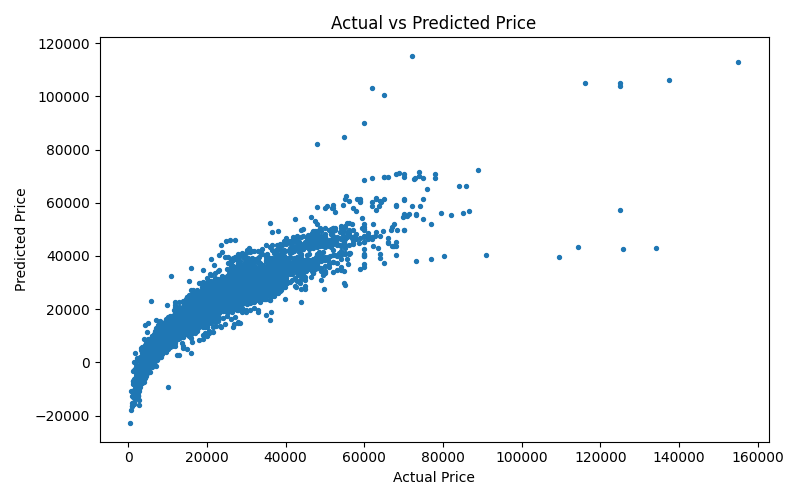

In [65]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, s=8)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")

plt.tight_layout()
plt.savefig("../outputs/charts/actual_vs_predicted.png")
plt.show()

### Interpretation

If the model predicts well, the points should be closer to a straight diagonal pattern. The graph helps us visually compare the actual prices with the predicted prices.

# 11. Conclusion

In this project, we used **Linear Regression** to predict the price of used cars.

The complete workflow included:

- Data collection
- Data understanding
- Data cleaning
- Exploratory Data Analysis
- Feature selection
- One-hot encoding
- Train-test split
- Linear Regression
- Prediction
- Model evaluation

The final model performance is based on MAE, MSE, RMSE and R² score. The results can be improved in future by trying other regression models and better feature engineering.

# Final Result

The final model metrics are shown below after running the notebook.